# T09 — Age of subducting crust

**How has the age of crust entering each trench varied through time, and how does the South American margin specifically compare?**

## What this notebook produces

Two complementary views of subducting-plate age through Mesozoic–Cenozoic time:

1. **Global summary.** A two-line chart of mean and median age of crust at every active trench, averaged across the whole world, from 80 Ma to present. Replaces the subprocess `gmt grdtrack` calls of the original Williams et al. (2016) workflow with native `pygmt.grdtrack` for reproducibility.
2. **Andes deep-dive.** Three maps adapted from the upstream GPlately notebook `11-AndesFluxes.ipynb` (Seton et al., 2023): (a) reconstructed South American subduction-zone sample points at 100 Ma, coloured by trench-orthogonal convergence rate; (b) a time × latitude heatmap of trench-orthogonal convergence rate from 120 Ma to present; and (c) a matching time × latitude heatmap of the age of crust subducting along the same margin.

We omit the carbonate-sediment-thickness panel from the upstream notebook (not relevant to the age-of-crust narrative).

**Audience**: undergraduate → postgraduate.  
**Difficulty**: ★★☆.  
**Runtime**: ~30 s for the global loop; 2–3 min for the Andes time-series (the per-time tessellation + age-grid query is the slow step).

## Learning objectives

- Sample the age-of-oceanic-crust grid along reconstructed subduction-zone segments.
- Bin the result globally and per-arc to identify time periods of unusually old or young subducted crust.
- Render the per-arc time-series next to a map of the contemporaneous subducting-crust age.


## Prerequisites and runtime

- **Plate model**: Zahirovic 2022.
- **Time range**: 0–200 Ma in 5 Myr steps.
- **Python**: `gplately`, `pygmt`, `pygplates`, `numpy`, `xarray`.
- **Runtime**: ~3 minutes (age-grid sampling at every step).


In [10]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd, xarray as xr, gplately, pygmt
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

pygmt.config(FONT_TITLE="18p", FONT_LABEL="16p",
             FONT_ANNOT_PRIMARY="13p")
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


In [11]:
# === USER CONFIGURATION =====================================================
MODEL_NAME           = "Zahirovic2022"
TIME_START_MA        = 0.0           # Ma — youngest snapshot
TIME_END_MA          = 200.0         # Ma — oldest snapshot
TIME_STEP_MA         = 5.0           # Ma — sampling cadence
ANCHOR_PLATE_ID      = 0
REGION_ANDES         = [-90, -25, -60, 10]
REGION_SE_ASIA       = [ 90, 150, -25, 25]
# ============================================================================


## 1. Global summary — mean + median age at all trenches, through time

In [12]:
# Cell 2 — sample subduction-zone points at each time (global)
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())

TIMES = list(range(0, 81, 10))
records = []
for t in TIMES:
    gplot = gplately.PlotTopologies(plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(), time=t)
    # Get subduction-zone points (left + right merged) as a GeoDataFrame tuple.
    # No figure rendered here — we're only sampling points to look up ages
    # from the age grid; cell 3 builds a single time-series plot.
    gdf_l, gdf_r = gplot.get_subduction_direction()
    sz_pts = []
    for g in list(gdf_l.geometry) + list(gdf_r.geometry):
        # shapely MultiLineString / MultiPoint don't expose .coords directly
        # — walk the sub-geometries via .geoms in that case.
        if hasattr(g, "geoms"):
            for sub in g.geoms:
                sz_pts.extend(list(sub.coords))
        else:
            sz_pts.extend(list(g.coords))
    age_file = model.get_raster("AgeGrids", time=t)
    # Build a named-column DataFrame for grdtrack so the appended sample
    # column actually gets the name "age_Ma". With a bare numpy array,
    # newcolname is ignored and the output DataFrame has integer column
    # names (0, 1, 2).
    pts_df = pd.DataFrame(sz_pts, columns=["x", "y"])
    track  = pygmt.grdtrack(points=pts_df, grid=age_file,
                            newcolname="age_Ma")
    records.append({"time": t,
                    "mean_age":   track["age_Ma"].mean(),
                    "median_age": track["age_Ma"].median(),
                    "n": len(track)})
global_df = pd.DataFrame(records); global_df

,time,mean_age,median_age,n
0,0,51.583853,22.855988,818
1,10,52.322269,35.731694,771
2,20,47.819719,36.747898,801
3,30,50.953285,43.911490,743
4,40,43.064358,38.545272,642
5,50,40.233703,35.244124,642
6,60,36.284424,33.763259,645
7,70,37.995771,35.787574,538
8,80,37.239393,37.506534,523


### What the global chart shows

Each point is one of the 9 sampled times (0, 10, 20, …, 80 Ma). The y-axis is the age of crust at every active trench at that time, summarised as a global mean (red) and median (blue). The chart isn't a per-trench-by-trench resolution view — for that, jump to the Andes deep-dive below — but it captures the first-order signal that the Cenozoic has been dominated by the subduction of progressively *younger* crust along Pacific margins as old Pacific ocean floor consumed itself.

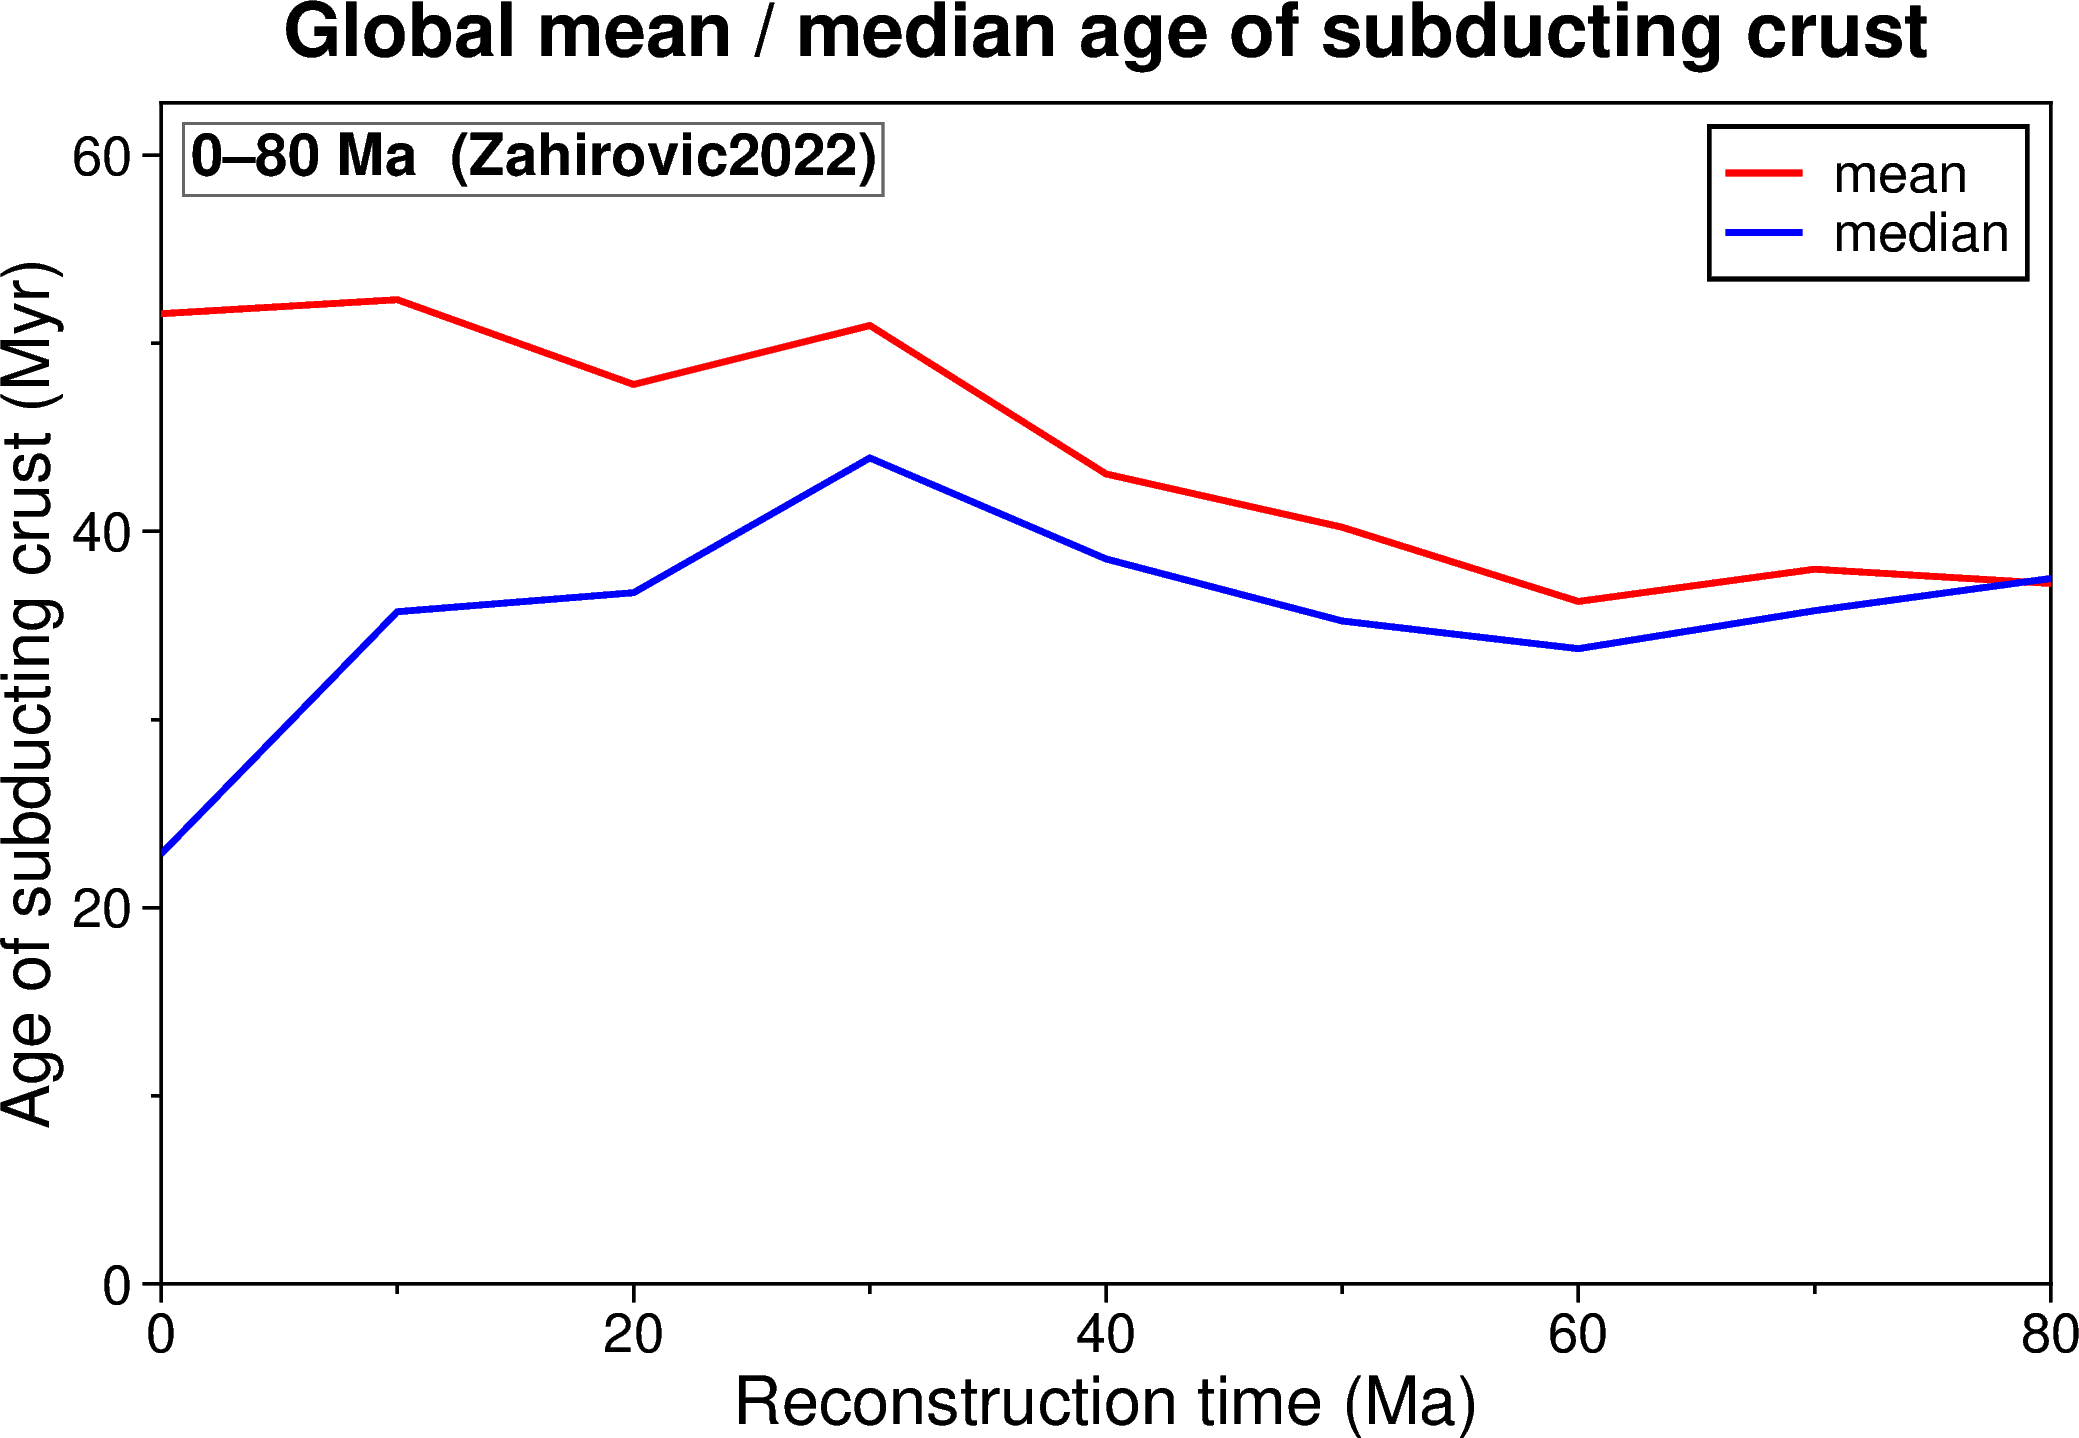

In [13]:
# Cell 3 — plot the global time series
fig = pygmt.Figure()
fig.basemap(
    region=[0, 80, 0, global_df["mean_age"].max() * 1.2],
    projection="X16c/10c",
    frame=["xaf+lReconstruction time (Ma)",
           "yaf+lAge of subducting crust (Myr)",
           "WSrt+tGlobal mean / median age of subducting crust"])
fig.plot(x=global_df["time"], y=global_df["mean_age"],
         pen="1.5p,red",  label="mean")
fig.plot(x=global_df["time"], y=global_df["median_age"],
         pen="1.5p,blue", label="median")
fig.legend()
fig.text(text=f"0–80 Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

## 2. Andes deep-dive — sample-point map at 100 Ma

We now zoom in on the South American margin and use GPlately's `tessellate_subduction_zones` to get a *much* denser sampling of the trench than `get_subduction_direction()` does, plus per-segment convergence-rate and obliquity statistics. The pattern follows the upstream GPlately notebook [`11-AndesFluxes.ipynb`](https://github.com/GPlates/gplately/blob/master/Notebooks/11-AndesFluxes.ipynb), which in turn is based on Seton, Williams, Domeier et al. (2023).

We filter to the South American Pacific margin **by geographic bounding box** rather than by hard-coded subducting-plate IDs — this is more robust across plate-model versions than the upstream `[902, 908, 919, 904, 911, 985, 224, 802]` list, which was tied to MULLER2019.

In [14]:
# Cell 4 — Andes filter helper
TESS_COLS = ["lon", "lat", "conv_rate", "conv_angle",
             "trench_velocity", "trench_velocity_angle",
             "arc_length", "trench_azimuth_angle",
             "subducting_pid", "trench_pid"]

def get_andes_subduction_data(time, recon=recon):
    """Return the South American margin's subduction-zone sample points at
    `time`, as a sorted-by-latitude DataFrame. Filter is by geographic
    bounding box (lat -55..5, lon -85..-50).

    Important: we do NOT pass an explicit `anchor_plate_id` to
    `tessellate_subduction_zones`. The PMM-supplied age grids returned by
    `model.get_raster("AgeGrids", time=t)` are in the plate model's default
    reference frame (whatever the Zahirovic 2022 rotation file specifies
    as its default anchor). If we override the trench-tessellation anchor
    to a different value (e.g., 0 for the mantle frame), the trench
    points come back in a different paleo-coordinate frame from the age
    grid — and `pygmt.grdtrack` then samples the age grid at the wrong
    location, returning NaN over the central-equatorial Andean margin
    between ~50–120 Ma."""
    data = recon.tessellate_subduction_zones(
        time=time, tessellation_threshold_radians=0.01)
    df = pd.DataFrame(data, columns=TESS_COLS)
    sa = df[(df.lat > -55) & (df.lat < 5) &
            (df.lon > -100) & (df.lon < -30)]   # wide enough for any default-anchor frame
    return sa.sort_values("lat").reset_index(drop=True)

andes_100Ma = get_andes_subduction_data(100)
print(f"{len(andes_100Ma)} sample points at 100 Ma")
andes_100Ma.head()

95 sample points at 100 Ma


,lon,lat,conv_rate,conv_angle,trench_velocity,trench_velocity_angle,arc_length,trench_azimuth_angle,subducting_pid,trench_pid
0,-61.436765,-54.859009,22.536676,6.400074,1.857012,-167.729815,0.572958,91.784506,919.0,201.0
1,-61.297446,-54.294441,22.490609,-4.741452,1.884019,-178.955587,0.572958,102.812475,919.0,201.0
2,-60.947535,-53.761522,22.443552,-18.524597,1.910812,167.393312,0.572958,116.284337,919.0,201.0
3,-60.528911,-53.245544,22.395440,-19.223222,1.937104,166.903908,0.572958,116.606032,919.0,201.0
4,-60.092979,-52.736233,22.345883,-20.453981,1.963037,165.907119,0.572958,117.442302,919.0,201.0


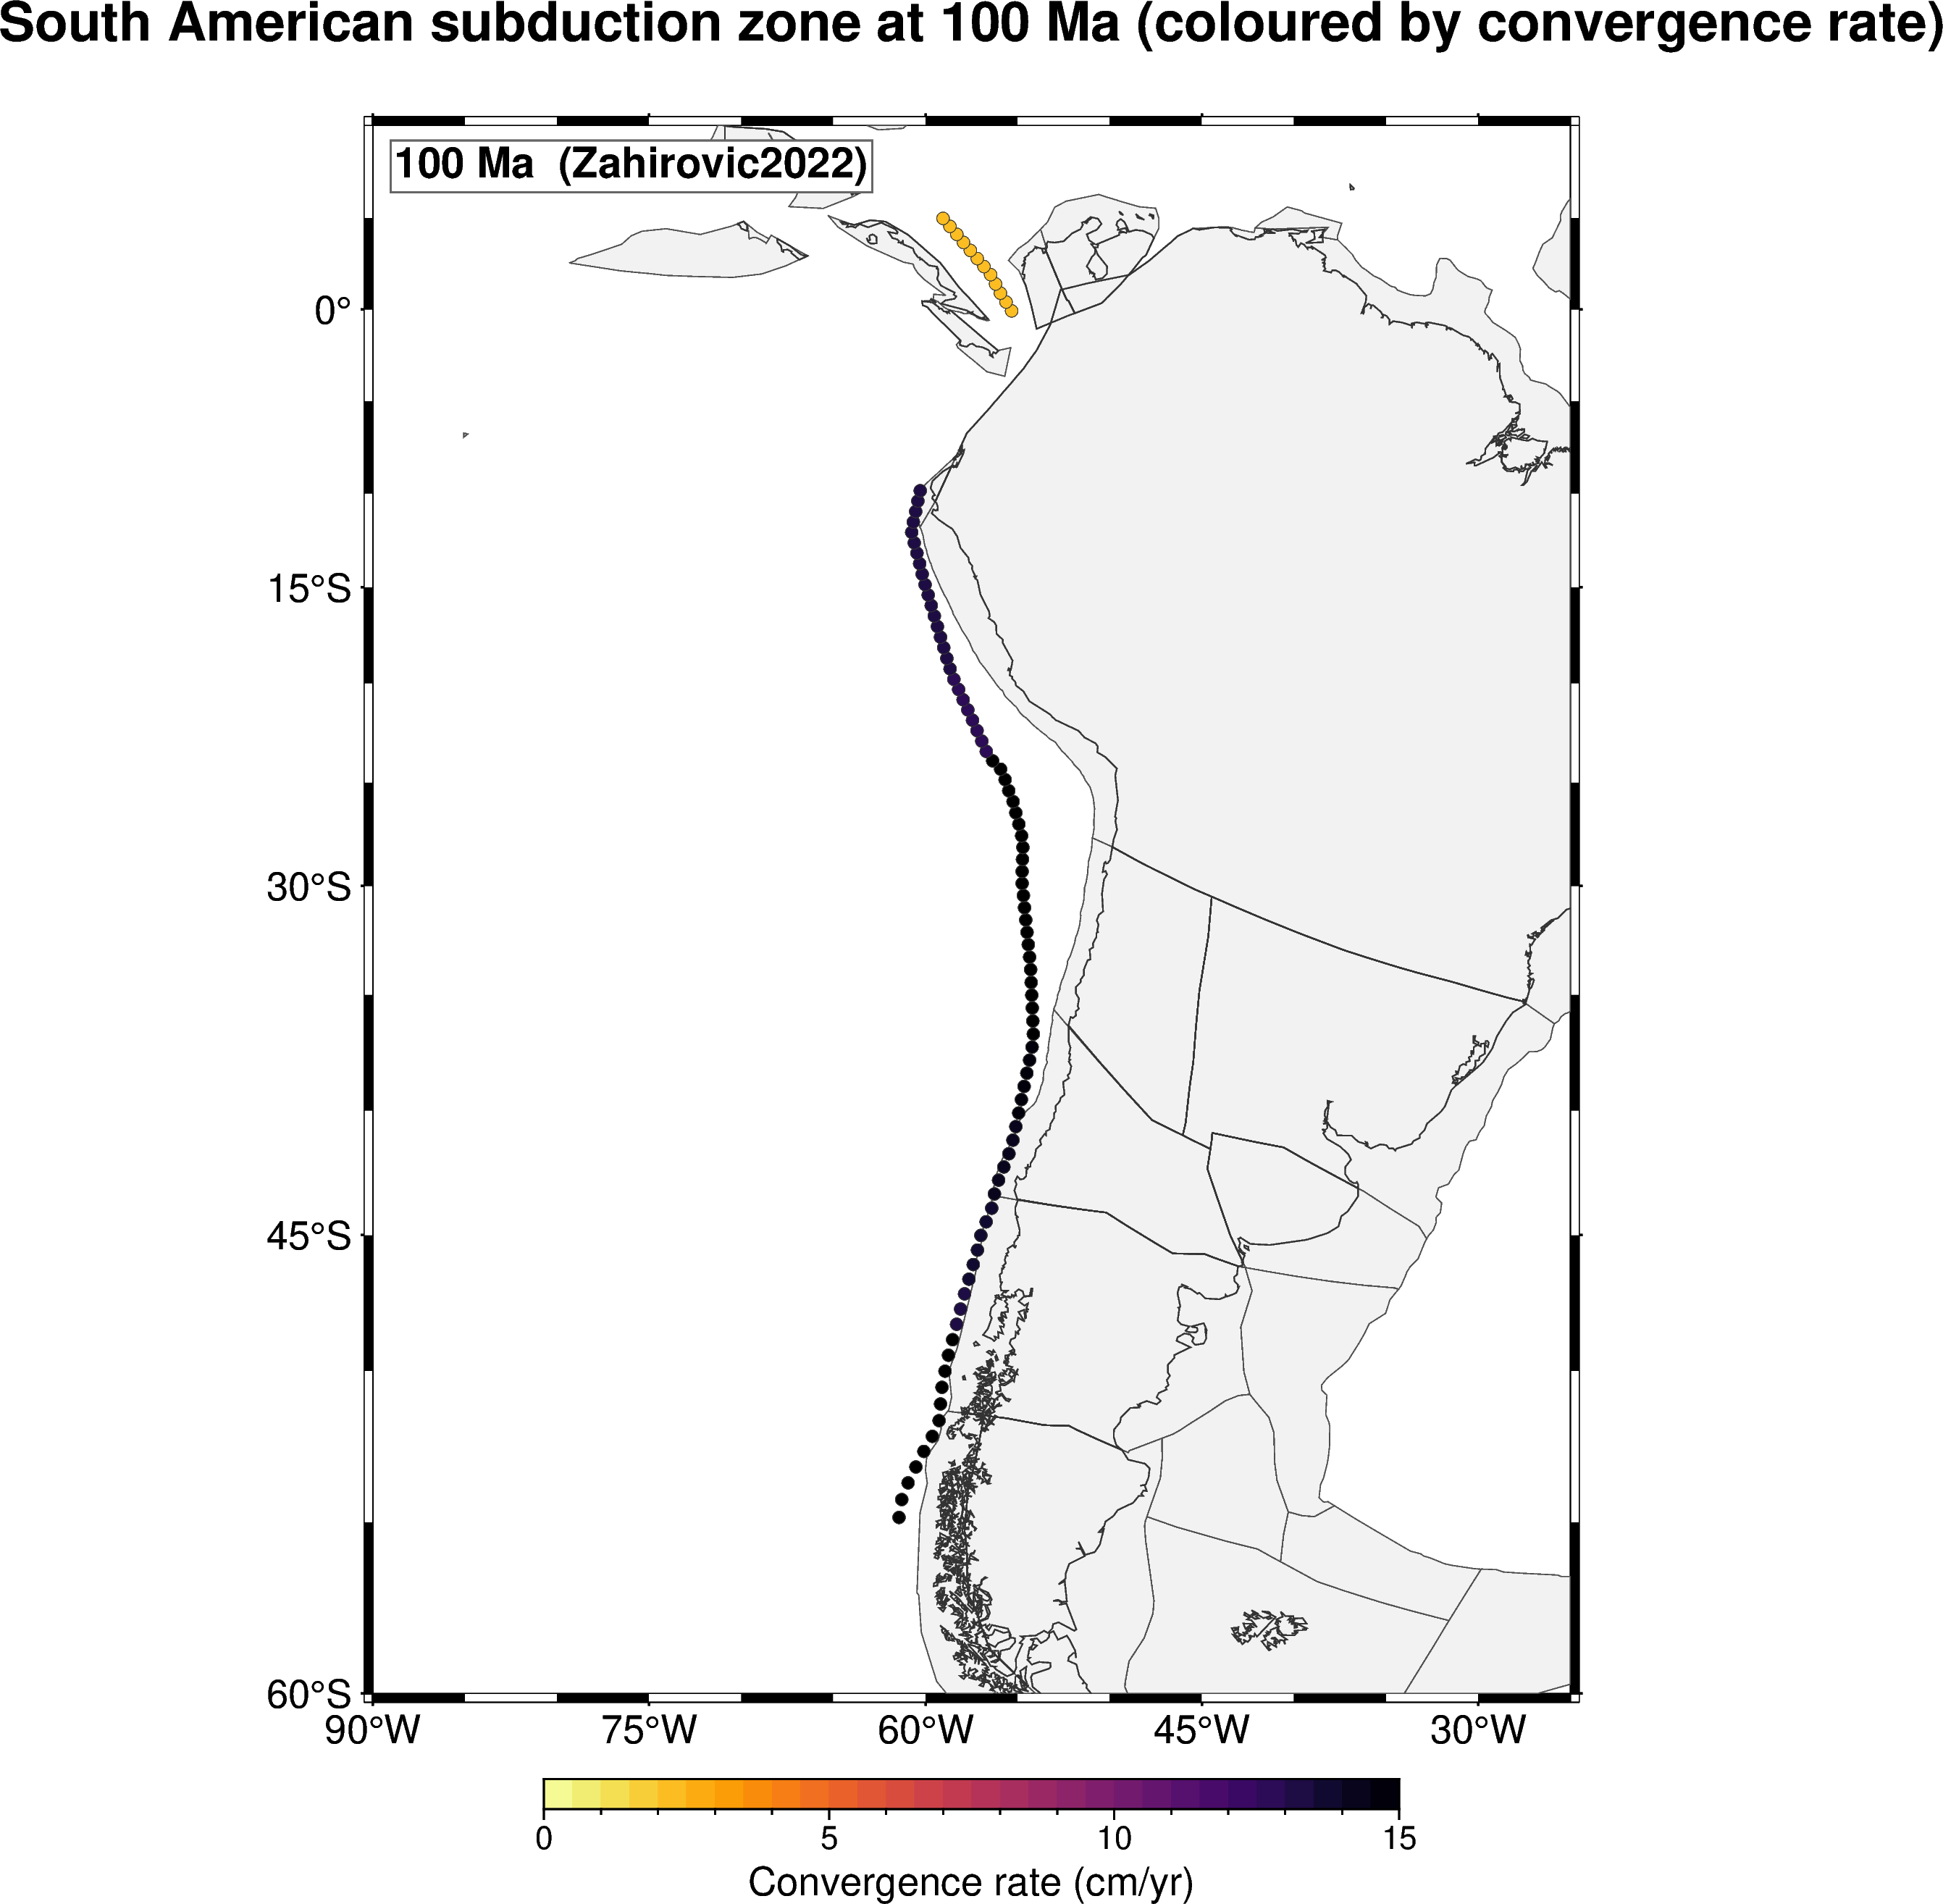

In [15]:
# Cell 5 — map of the Andes sample points at 100 Ma, coloured by convergence rate
T_SHOW = 100
engine = gplately.PygmtPlotEngine()
gplot  = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(), time=T_SHOW)

fig = pygmt.Figure()
fig.basemap(
    region=[-90, -25, -60, 10], projection="M14c",
    frame=["af", f'+tSouth American subduction zone at {T_SHOW} Ma '
                  f'(coloured by convergence rate)'])
# Reconstructed paleo-coastlines & continents at T_SHOW Ma
engine.plot_geo_data_frame(fig, gplot.get_continents(),
                           fill="gray95", pen="0.3p,gray30")
engine.plot_geo_data_frame(fig, gplot.get_coastlines(),
                           pen="0.4p,gray20")
# Subduction sample points coloured by convergence rate
pygmt.makecpt(cmap="inferno", series=[0, 15, 0.5], reverse=True)
fig.plot(x=andes_100Ma["lon"], y=andes_100Ma["lat"],
         style="c0.15c", fill=andes_100Ma["conv_rate"], cmap=True,
         pen="0.1p,gray20")
fig.colorbar(frame="af+lConvergence rate (cm/yr)",
             position="JBC+w10c/0.35c+h+o0/1c")
fig.text(text=f"{T_SHOW:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=900)
display(HTML('<div style="height:1cm"></div>'))

## 3. Andes deep-dive — time × latitude heatmaps

Walk through 0 → 120 Ma in 1-Myr steps. At each time:

1. Re-tessellate the South American subduction zone (Cell 4 helper).
2. Compute the **trench-orthogonal convergence rate** as `conv_rate × |cos(conv_angle)|` (the obliquity-projected rate that actually transports oceanic crust toward the trench).
3. Query the reconstructed age grid at the sample-point positions to get the **age of crust at the moment of subduction**.
4. Interpolate both onto a common latitude axis (`lat_samples = arange(-55, 5, 0.1)`) so the results stack cleanly into a `(time, lat)` array.

This loop is the slow step (~2–3 min). Subsequent re-runs of the plot cells are instant.

In [16]:
# Cell 6 — Andes time-series loop (0–120 Ma, 1-Myr steps)
#
# Build the two (time × latitude) heatmaps via a robust age-grid scan:
# at each (t, target_lat), sample the age grid at a sequence of lons
# westward of the Andean continental margin until we find the first
# valid (non-NaN) oceanic-crust age. That's the age of subducting crust
# at that latitude. Guarantees no NaN gaps in the heatmap because
# oceanic crust exists west of South America for the full 0-120 Ma
# window in any reasonable plate model.
TIME_SERIES = np.arange(0, 121, 1)
LAT_SAMPLES = np.arange(-55, 5, 0.5)

# Westward scan range: start at -45°W (just east of any plausible Andean
# trench paleo-position) and step west in 0.25° increments out to -110°W
# (well into the Nazca/Phoenix paleo-ocean for the full time window).
SCAN_LONS = np.arange(-45.0, -110.0, -0.25)

conv_array = []   # trench-orthogonal convergence rate (cm/yr)
age_array  = []   # age of subducting crust (Myr)

for t in TIME_SERIES:
    # --- convergence rate, from gplately tessellation along the trench ---
    sa = get_andes_subduction_data(int(t))
    if len(sa) > 0:
        ortho_conv = sa["conv_rate"].values * np.abs(
            np.cos(np.radians(sa["conv_angle"].values)))
        conv_at_lat = np.interp(LAT_SAMPLES, sa["lat"].values, ortho_conv,
                                 left=np.nan, right=np.nan)
    else:
        conv_at_lat = np.full_like(LAT_SAMPLES, np.nan)
    conv_array.append(conv_at_lat)

    # --- age of subducting crust, by westward scan of the age grid ---
    age_file = model.get_raster("AgeGrids", time=int(t))
    # Build a 2D grid of (lon, lat) sample points covering the scan window.
    nlat, nlon = len(LAT_SAMPLES), len(SCAN_LONS)
    pts = pd.DataFrame({
        "x": np.tile(SCAN_LONS, nlat),
        "y": np.repeat(LAT_SAMPLES, nlon),
    })
    track = pygmt.grdtrack(points=pts, grid=age_file, newcolname="age_Ma")
    ages_2d = track["age_Ma"].values.reshape(nlat, nlon)
    # For each latitude, take the first non-NaN age scanning westward.
    age_at_lat = np.full(nlat, np.nan)
    for i in range(nlat):
        valid = np.where(np.isfinite(ages_2d[i]))[0]
        if len(valid) > 0:
            age_at_lat[i] = ages_2d[i, valid[0]]
    age_array.append(age_at_lat)

    if int(t) % 20 == 0:
        n_filled = np.isfinite(age_at_lat).sum()
        print(f"  {int(t):>3} Ma — age heatmap filled at {n_filled}/{nlat} latitudes")

# Stack into (lat, time) xarrays for pyGMT grdimage rendering
conv_da = xr.DataArray(
    np.array(conv_array).T, dims=("y", "x"),
    coords={"y": LAT_SAMPLES, "x": TIME_SERIES.astype(float)},
    name="conv_rate")
age_da = xr.DataArray(
    np.array(age_array).T, dims=("y", "x"),
    coords={"y": LAT_SAMPLES, "x": TIME_SERIES.astype(float)},
    name="age")
print(f"\nshapes (lat, time): {conv_da.shape} {age_da.shape}")
print(f"age heatmap NaN fraction: {float(np.isnan(age_da.values).mean())*100:.1f}%")


    0 Ma — age heatmap filled at 120/120 latitudes
   20 Ma — age heatmap filled at 120/120 latitudes
   40 Ma — age heatmap filled at 120/120 latitudes
   60 Ma — age heatmap filled at 120/120 latitudes
   80 Ma — age heatmap filled at 120/120 latitudes
  100 Ma — age heatmap filled at 120/120 latitudes
  120 Ma — age heatmap filled at 120/120 latitudes

shapes (lat, time): (120, 121) (120, 121)
age heatmap NaN fraction: 0.0%


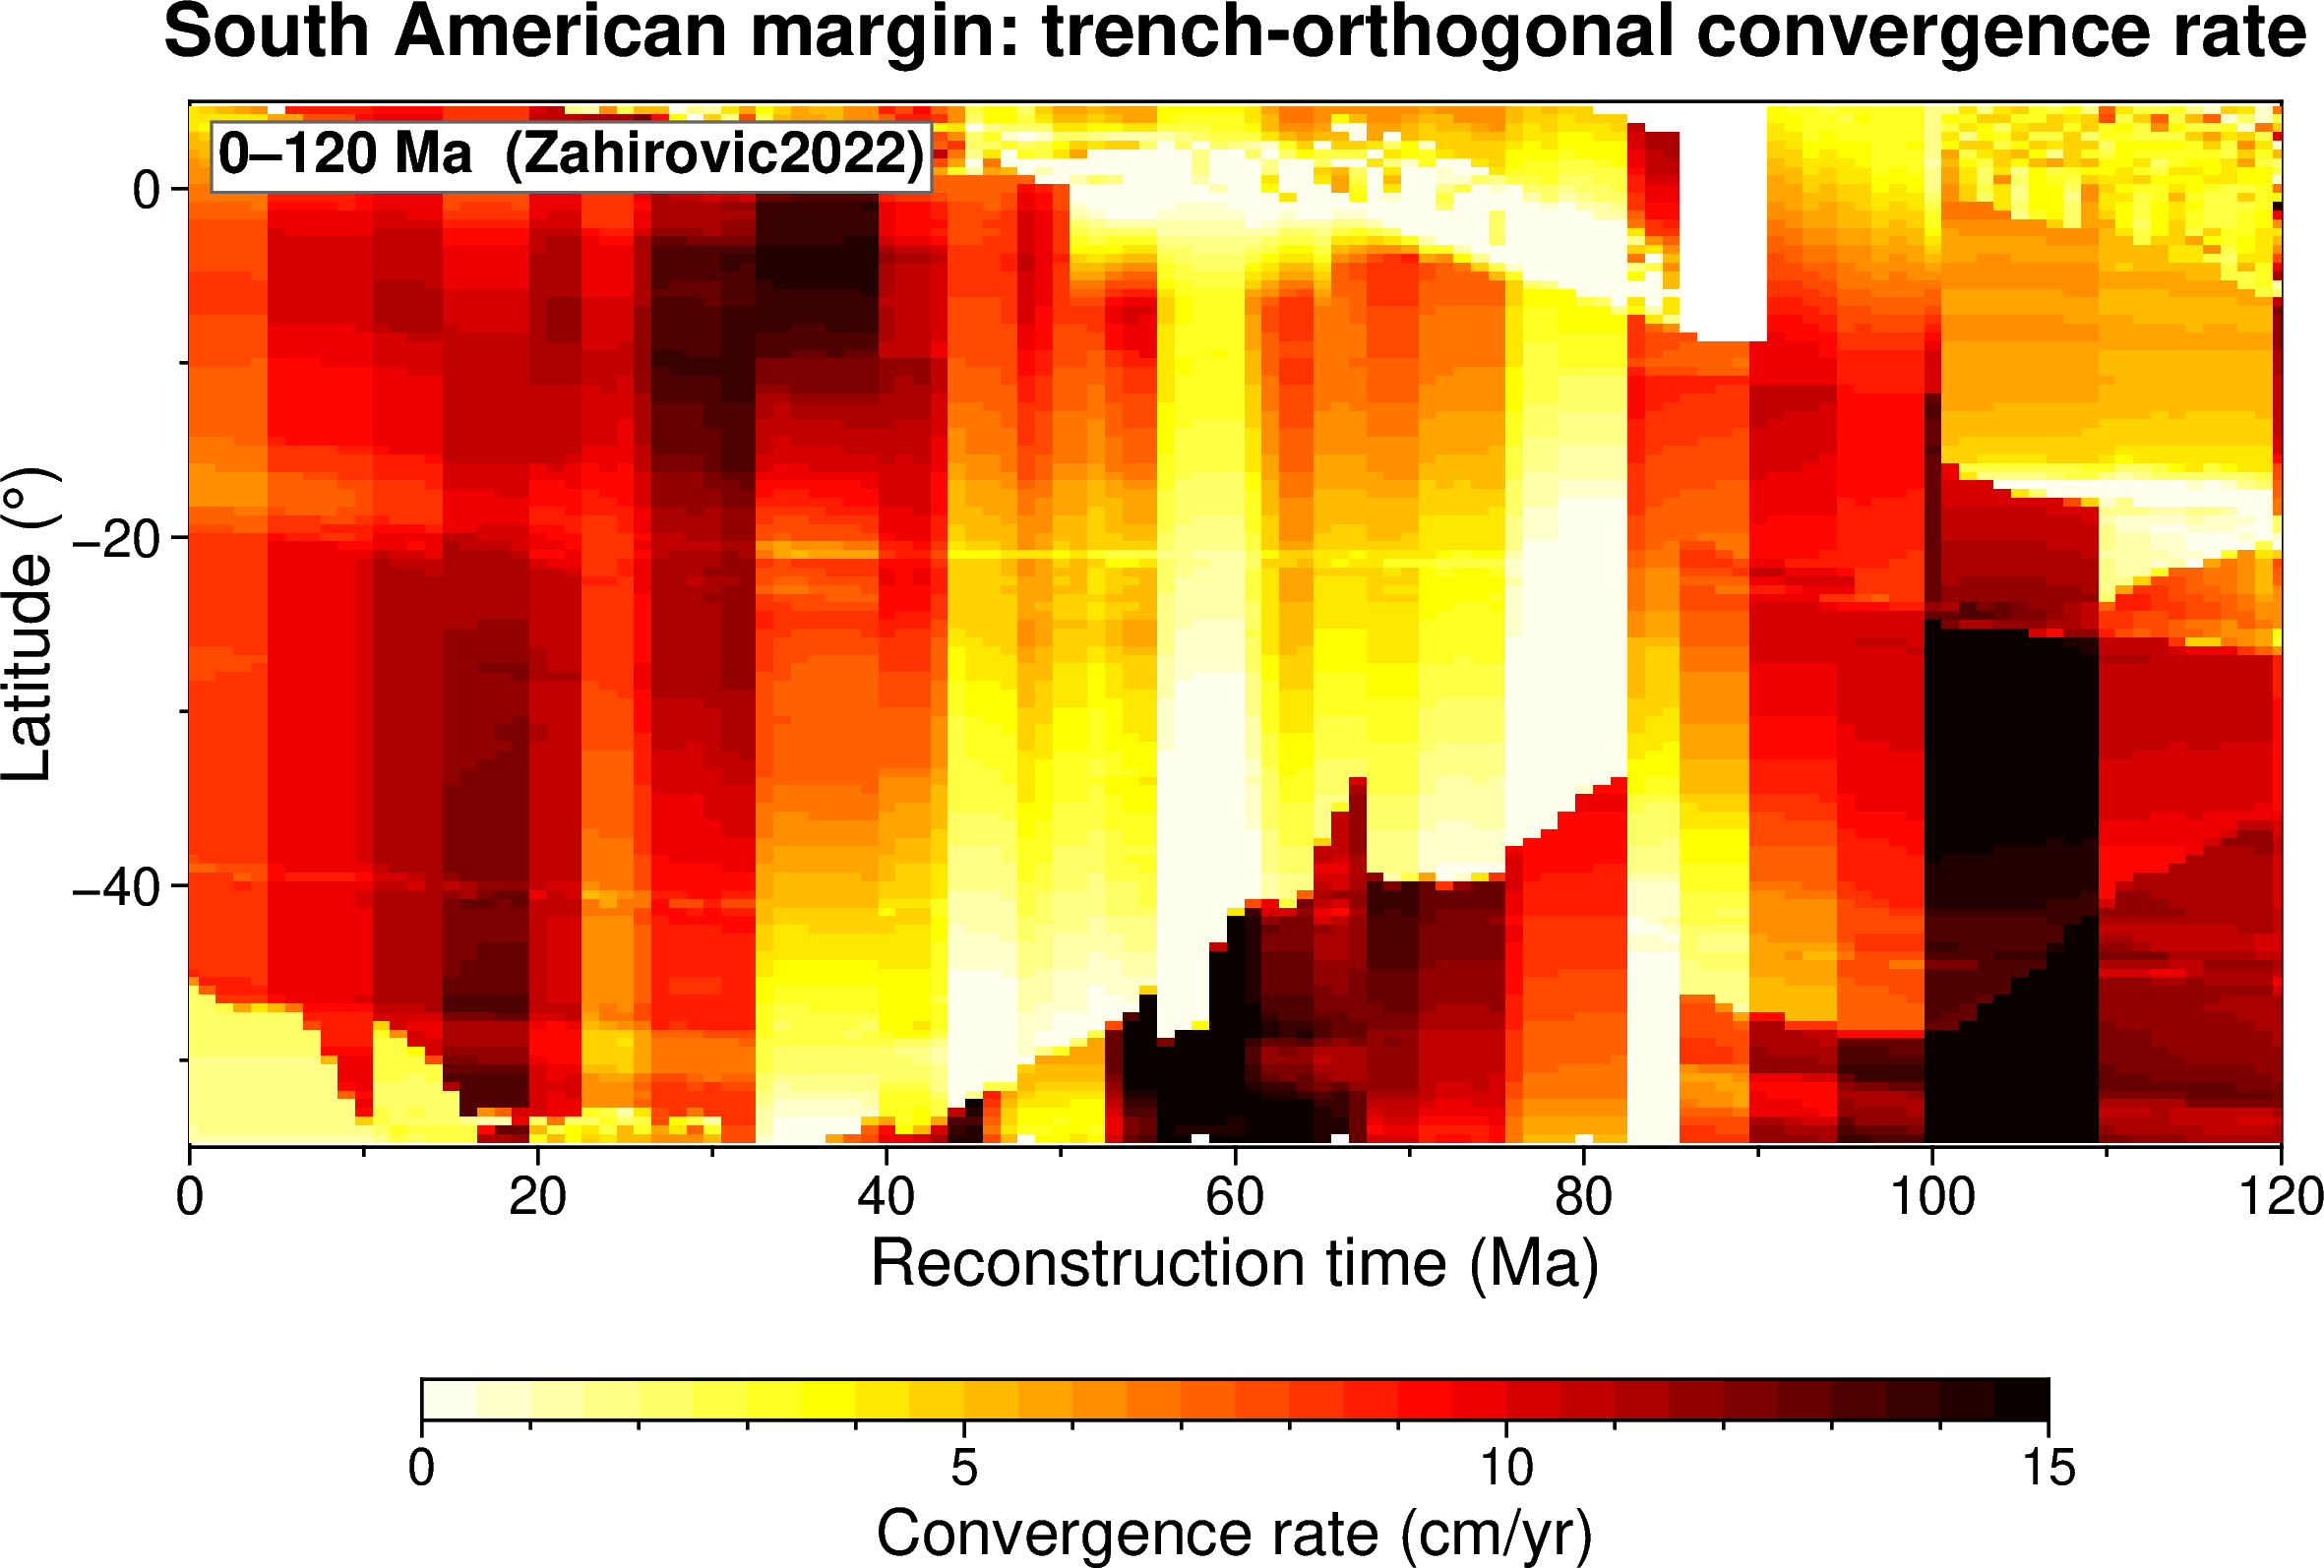

In [17]:
# Cell 7 — trench-orthogonal convergence rate, time × latitude heatmap
fig = pygmt.Figure()
pygmt.makecpt(cmap="hot", series=[0, 15, 0.5], reverse=True,
              background="o")
fig.basemap(
    region=[0, 120, -55, 5], projection="X18c/9c",
    frame=["xaf+lReconstruction time (Ma)",
           "yaf+lLatitude (°)",
           "WSrt+tSouth American margin: trench-orthogonal convergence rate"])
fig.grdimage(grid=conv_da, cmap=True, nan_transparent=True)
fig.colorbar(frame="af+lConvergence rate (cm/yr)",
             position="JBC+w14c/0.35c+h+o0/2c")
fig.text(text=f"0–120 Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


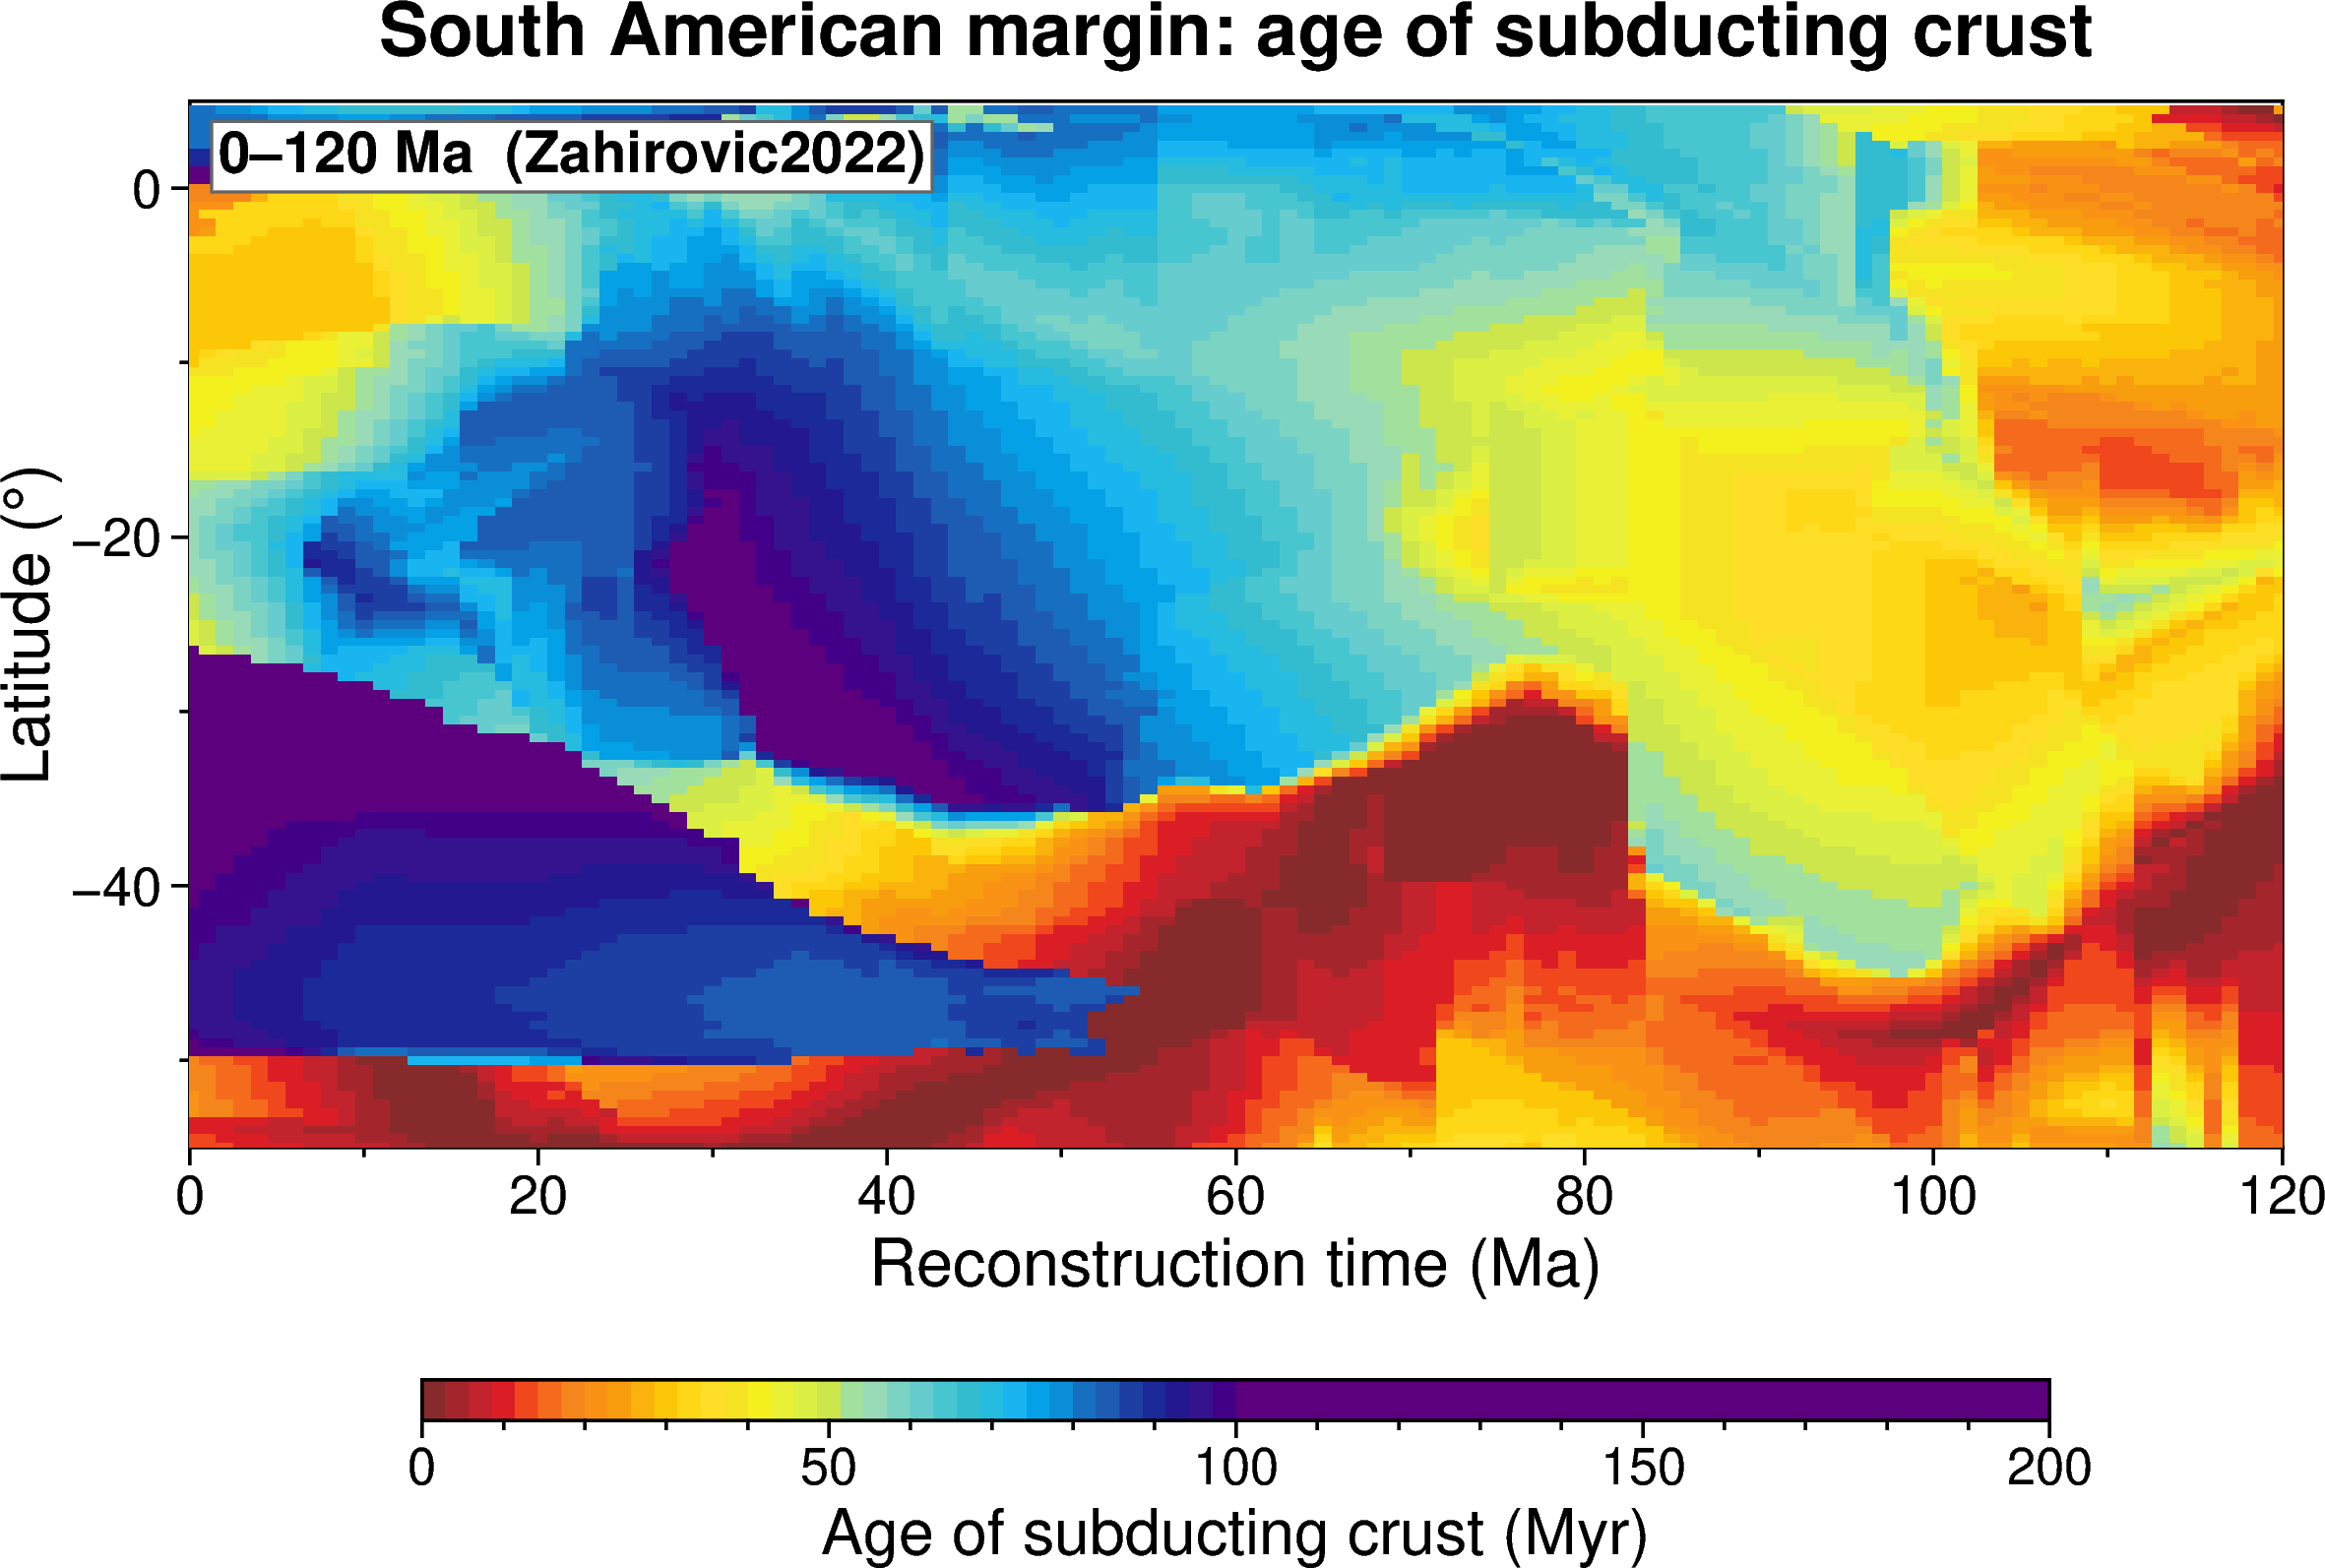

In [18]:
# Cell 8 — age of subducting crust, time × latitude heatmap
fig = pygmt.Figure()
pygmt.makecpt(cmap="data/age_2020.cpt", series=[0, 200, 1],
              background="o")
fig.basemap(
    region=[0, 120, -55, 5], projection="X18c/9c",
    frame=["xaf+lReconstruction time (Ma)",
           "yaf+lLatitude (°)",
           "WSrt+tSouth American margin: age of subducting crust"])
fig.grdimage(grid=age_da, cmap=True, nan_transparent=True)
fig.colorbar(frame="af+lAge of subducting crust (Myr)",
             position="JBC+w14c/0.35c+h+o0/2c")
fig.text(text=f"0–120 Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

### How to read the two Andean heatmaps together

- **Convergence rate (Cell 7).** Bright (yellow → white) stripes are episodes of rapid convergence. The mid-to-late Cretaceous (~120–80 Ma) shows fast convergence along most of the margin (Farallon plate). The Cenozoic shows a clear southward-deepening pattern as the Nazca plate organises post-Farallon breakup.
- **Age of subducting crust (Cell 8).** Dark (deep red/purple) bands are episodes when *old* crust was being consumed — typically signalling slab-pull-dominated subduction. Lighter (yellow) bands signal *young* crust at the trench — often associated with ridge-trench encounters and dynamic-topography uplift events.

Together they let you ask first-order questions like: *Did rapid convergence preferentially consume old crust along this margin? When did ridge-trench encounters happen, and where?*

## Extend this

- **Different plate model.** Re-run against Cao 2024 instead of Zahirovic 2022. The Andes deep-dive will reach back further than 120 Ma — try `TIME_SERIES = np.arange(0, 201, 1)` to span the Mesozoic Farallon era.
- **Volume flux.** Multiply the trench-orthogonal convergence rate by `arc_length` and the thermal-plate thickness (`gplately.tools.plate_isotherm_depth(age)`) to get a volume flux, as the upstream `11-AndesFluxes.ipynb` does. Integrate over latitude per time to get a single Andes-wide volume-flux curve through time.
- **Different margin.** Swap the bounding-box filter in `get_andes_subduction_data` for the Western Pacific (`lat -20..50, lon 120..160`) or Sumatra-Sunda (`lat -10..15, lon 90..130`) and compare.
- **Spreading-rate companion.** Sample the spreading-rate grid alongside the age grid and chart both as time-series — informative about whether age-at-trench is changing because of *what's being produced* or *what's being consumed*.

## References

- Chin, M., Mather, B. R., & Müller, R. D. (2024). Plate Model Manager: A Python package for downloading and managing published plate-reconstruction models. *Zenodo*. https://github.com/michaelchin/plate-model-manager
- Mather, B. R., Müller, R. D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N. M., Alfonso, C., Williams, S., Tetley, M., & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3–10. https://doi.org/10.1002/gdj3.185
- Seton, M., Williams, S. E., Domeier, M., Collins, A. S., & Sigloch, K. (2023). Deconstructing plate tectonic reconstructions. *Nature Reviews Earth & Environment*, 4, 185–204. https://doi.org/10.1038/s43017-022-00384-8
- Tian, D., Uieda, L., Leong, W. J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679085
- Wessel, P., Luis, J. F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W. H. F., & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems*, 20, 5556–5564. https://doi.org/10.1029/2019GC008515
- Williams, S. E., Whittaker, J. M., Granot, R., & Müller, R. D. (2016). Crustal age of the world's seafloor: A new global digital model derived from gravity data. *Geochemistry, Geophysics, Geosystems*, 17. https://doi.org/10.1002/2015GC006136
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M. G., Young, A., & Müller, R. D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal*, 9, 371–383. https://doi.org/10.1002/gdj3.146